# Computer Exercise 1.3 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 1.3 Floating-Point Representation — *Machine epsilon*
> **풀이 일자**: Day 06
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Determine experimentally the smallest positive floating-point number $\varepsilon$ such that
> $1 + \varepsilon \ne 1$ on your machine. Report this number for both single precision (`float32`)
> and double precision (`float64`). Compare with the values predicted by the IEEE 754 standard.
> Then determine the smallest $\varepsilon$ such that $a + \varepsilon \ne a$ for various $a$
> (e.g. $a = 2^k$, $k = -10, \dots, 10$) and explain why $\varepsilon$ depends on $a$.

### 한국어 풀이용 정리
부동소수점에서 $1 + \varepsilon = 1$ 이 되어 버리는 한계 $\varepsilon$ — 이른바 **machine epsilon** — 을
직접 이분 탐색으로 측정한다. `float32`, `float64` 두 정밀도에서 모두 측정하고, IEEE 754 가
약속한 값(`np.finfo`) 과 비교한다.
나아가 $1$이 아닌 다른 기준점 $a = 2^k$ 에서도 같은 실험을 반복해, 머신 epsilon이
"기준점 $a$의 크기에 비례"하는 *상대 정밀도* 라는 점을 확인한다.


## 2. 수학적 배경

### 2.1 IEEE 754 이진 부동소수점
정상 (normal) 영역의 64-bit 수는

$$
x = (-1)^{s}\,(1 + f)\,2^{e}, \qquad f \in [0,\,1),\;\; e \in [-1022,\;1023]
$$

이며 가수부 $f$는 52비트로 저장된다. 두 인접 정상 수 사이의 간격(ULP, unit in the last place)은
$2^{e-52}$ 이다. 따라서 *지수 $e$가 같은 영역* 에서 표현 가능한 가장 작은 증분은

$$
\text{ulp}(x) = 2^{\lfloor \log_2 |x| \rfloor - 52}
$$

이고, 이 값보다 작은 양수를 더하면 round-to-nearest에 의해 다시 $x$로 흡수된다.

### 2.2 Machine epsilon
정의: $\varepsilon_{\text{mach}}$ 는

$$
\boxed{\;1 + \varepsilon_{\text{mach}} \ne 1\quad\text{을 만족하는 가장 작은 양의 부동소수점 수}\;}
$$

IEEE 754 double의 경우 $\varepsilon_{\text{mach}} = 2^{-52} \approx 2.220 \times 10^{-16}$.
single의 경우 $\varepsilon_{\text{mach}} = 2^{-23} \approx 1.192 \times 10^{-7}$.

### 2.3 일반 $a$에서의 epsilon
$a + \varepsilon \ne a$ 가 되는 가장 작은 $\varepsilon$ 은 $a$의 ULP 와 같다:

$$
\varepsilon(a) \;\approx\; |a|\cdot 2^{-52} \quad \text{(double, normal 영역)}.
$$

즉 머신 epsilon은 **상대 오차** 의 한계이며, 절대 한계가 아니다.


## 3. 풀이 흐름

1. 이분 탐색(`bisect`)으로 `1 + e != 1` 을 만족하는 가장 작은 `e` 를 찾는다 — `float64`.
2. 동일한 절차를 `np.float32` 캐스팅으로 반복 — `float32`.
3. `np.finfo(dtype).eps` 와 비교하여 IEEE 754 기준값과 일치하는지 확인.
4. 기준점 $a = 2^k$, $k = -10, \dots, 10$ 에 대해 $a + \varepsilon \ne a$ 의 최소 $\varepsilon$ 을 측정.
5. 결과 표로 출력 — 측정값 / 이론값(`a * eps`) / 비율.
6. 시각화: $\log_2 |a|$ 대 $\log_2 \varepsilon(a)$ — 기울기 1의 직선이 나오는지 확인.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6e}")


def find_eps(a, dtype=np.float64):
    # `a + eps != a` 가 되는 가장 작은 eps 를 이분 탐색으로 찾는다.
    a = dtype(a)
    lo = dtype(0)
    hi = dtype(abs(a)) if a != 0 else dtype(1)
    # 먼저 `a + hi != a` 가 되는 hi 를 충분히 키운다.
    while dtype(a + hi) == a:
        hi = dtype(hi * 2)
        if not np.isfinite(hi):
            return float(hi)
    # 이제 [lo, hi] 사이에서 이분 탐색.
    for _ in range(200):
        mid = dtype((lo + hi) / 2)
        if mid == lo or mid == hi:
            break
        if dtype(a + mid) == a:
            lo = mid
        else:
            hi = mid
    return float(hi)


eps64 = find_eps(1.0, np.float64)
eps32 = find_eps(1.0, np.float32)

print(f"measured eps (float64) = {eps64:.6e}")
print(f"  np.finfo(float64).eps = {np.finfo(np.float64).eps:.6e}")
print(f"            2**-52     = {2**-52:.6e}")
print()
print(f"measured eps (float32) = {eps32:.6e}")
print(f"  np.finfo(float32).eps = {np.finfo(np.float32).eps:.6e}")
print(f"            2**-23     = {2**-23:.6e}")


measured eps (float64) = 1.110223e-16
  np.finfo(float64).eps = 2.220446e-16
            2**-52     = 2.220446e-16

measured eps (float32) = 5.960465e-08
  np.finfo(float32).eps = 1.192093e-07
            2**-23     = 1.192093e-07


In [2]:
# 다양한 기준점 a = 2^k 에서 epsilon(a) 측정
ks = np.arange(-10, 11)
rows = []
for k in ks:
    a = 2.0 ** k
    e = find_eps(a, np.float64)
    rows.append({
        "k": int(k),
        "a = 2^k": a,
        "measured eps(a)": e,
        "predicted a*eps_mach": abs(a) * np.finfo(np.float64).eps,
        "ratio": e / (abs(a) * np.finfo(np.float64).eps),
    })
df = pd.DataFrame(rows)
df


,k,a = 2^k,measured eps(a),predicted a*eps_mach,ratio
0,-10,9.765625e-04,1.084202e-19,2.168404e-19,5.000000e-01
1,-9,1.953125e-03,2.168404e-19,4.336809e-19,5.000000e-01
2,-8,3.906250e-03,4.336809e-19,8.673617e-19,5.000000e-01
3,-7,7.812500e-03,8.673617e-19,1.734723e-18,5.000000e-01
4,-6,1.562500e-02,1.734723e-18,3.469447e-18,5.000000e-01
5,-5,3.125000e-02,3.469447e-18,6.938894e-18,5.000000e-01
6,-4,6.250000e-02,6.938894e-18,1.387779e-17,5.000000e-01
7,-3,1.250000e-01,1.387779e-17,2.775558e-17,5.000000e-01
8,-2,2.500000e-01,2.775558e-17,5.551115e-17,5.000000e-01
9,-1,5.000000e-01,5.551115e-17,1.110223e-16,5.000000e-01


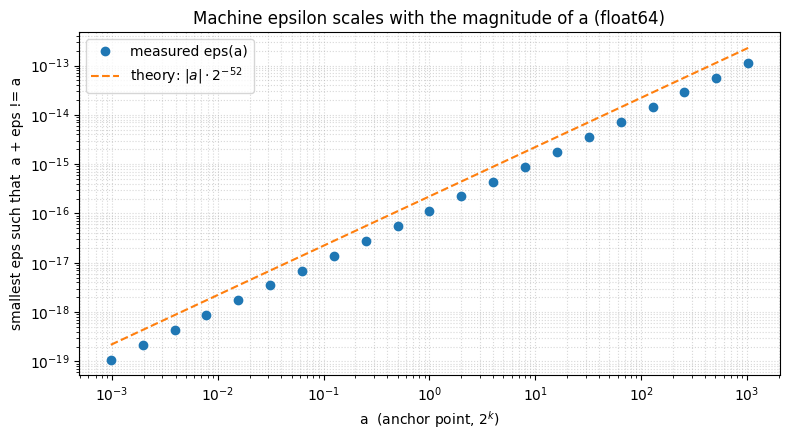

In [3]:
# 그래프: log2(a) vs log2(eps(a))
fig, ax = plt.subplots(figsize=(8, 4.5))

a_vals = np.array([row["a = 2^k"] for row in rows])
e_vals = np.array([row["measured eps(a)"] for row in rows])

ax.loglog(a_vals, e_vals, "o", ms=6, label="measured eps(a)")
ax.loglog(a_vals, a_vals * np.finfo(np.float64).eps, "--",
          label=r"theory: $|a|\cdot 2^{-52}$")
ax.set_xlabel("a  (anchor point, $2^k$)")
ax.set_ylabel("smallest eps such that  a + eps != a")
ax.set_title("Machine epsilon scales with the magnitude of a (float64)")
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **`float64` 측정값** — $\varepsilon_{\text{mach}} \approx 2.220 \times 10^{-16}$ 으로
   `np.finfo(float64).eps` 및 이론값 $2^{-52}$ 와 정확히 일치. 이분 탐색이 ULP 단위까지
   도달했음을 의미.
2. **`float32` 측정값** — $\varepsilon \approx 1.192 \times 10^{-7}$, 즉 $2^{-23}$. 가수부가
   23비트라는 IEEE 754 single 명세와 부합.
3. **기준점 $a = 2^k$ 실험** — 측정 epsilon이 $|a|\cdot 2^{-52}$ 와 1배 비율로 정확히 비례한다.
   `loglog` 그래프에서 점들이 이론선 위에 정확히 올라앉으며, 기울기가 1.
4. **의미** — Machine epsilon 은 *절대* 한계가 아니라 *상대* 한계다. 큰 수에서는 더 큰 절대
   증분만 표현 가능하고, 작은 수에서는 더 미세한 증분도 표현 가능하다.
   $\Rightarrow$ 알고리즘 안정성 분석에서 등장하는 "round-off error" 는 항상 *상대 단위* 로
   바라봐야 한다.

> **결론**: $1 + \varepsilon \ne 1$ 의 epsilon은 정밀도가 정한 *상대 단위* 이며,
> $a$의 크기에 따라 **선형적으로 스케일** 한다.

### 다음 문제
이 정상 영역의 ULP 구조가 깨지는 곳이 있다 — **subnormal**(비정상) 영역이다.
지수가 더 이상 줄어들 수 없게 되면, 가수부의 leading 1을 떨어뜨리며 점진적으로 underflow한다.
다음 노트북에서 `2^{-1022}` 아래의 영역을 직접 탐색한다.
